# 01 — E-GEO Full ML Pipeline for Google Colab

This notebook is the Google Colab version of the full E-GEO ML pipeline.

It assumes your Google Drive folder is exactly:

```text
/content/drive/MyDrive/Finance Research/E-GEO-ML
```

Expected Drive structure:

```text
E-GEO-ML/
├── code/
│   └── 01_egeo_full_ml_pipeline_colab.ipynb
├── raw_data/
│   ├── train_val_data.json
│   ├── test_data.json
│   ├── train_val_initial_ranking_gpt5.json
│   ├── train_val_initial_ranking_gemini.json
│   ├── train_val_initial_ranking_claude.json
│   └── ...
├── data/       # created by this notebook
├── figures/    # created by this notebook
├── results/    # created by this notebook
└── models/     # created by this notebook
```

Important:

- `code/`, `raw_data/`, `data/`, `figures/`, `results/`, and `models/` are all siblings under `E-GEO-ML/`.
- The notebook can be placed inside `code/`.
- All cleaned datasets, ML-ready CSV files, metrics, figures, and trained models are saved to the project-level folders, not inside `code/`.
- This notebook uses existing E-GEO JSON ranking traces. It does not call any LLM API.


## 0. Colab package installation

Run this once at the beginning of the Colab session.  
Colab already has most packages, but this ensures optional models such as XGBoost and LightGBM are available.


In [1]:
# Google Colab / JupyterLab install cell
%pip install -q -U xgboost lightgbm joblib


## Colab runtime note

For the full run, CPU is enough, but it may take time.  
For faster tree/boosting models, you can use:

```text
Runtime → Change runtime type → T4 GPU
```

This notebook itself does not require GPU because it uses classical ML, TF-IDF, Random Forest, XGBoost/LightGBM, and ranking diagnostics.


## 1. Imports and folder setup

In [2]:
from pathlib import Path
import json
import ast
import re
import math
import warnings
import joblib
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier, Ridge
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
)
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")

# ============================================================
# Google Colab + Google Drive project path
# ============================================================
# Your exact project location:
# /content/drive/MyDrive/Finance Research/E-GEO-ML
# ============================================================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/Finance Research/E-GEO-ML")

# Fallback for local JupyterLab if not running in Colab.
if not PROJECT_ROOT.exists():
    CWD = Path.cwd().resolve()
    if (CWD / "raw_data").exists():
        PROJECT_ROOT = CWD
    elif (CWD.parent / "raw_data").exists():
        PROJECT_ROOT = CWD.parent
    else:
        PROJECT_ROOT = CWD.parent if CWD.name.lower() == "code" else CWD

CODE_DIR = PROJECT_ROOT / "code"
RAW_DATA_DIR = PROJECT_ROOT / "raw_data"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

for d in [CODE_DIR, DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("Project root:", PROJECT_ROOT)
print("Code directory:", CODE_DIR)
print("Raw data directory:", RAW_DATA_DIR)
print("Output data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)
print("Models directory:", MODELS_DIR)

assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
assert RAW_DATA_DIR.exists(), f"raw_data folder not found: {RAW_DATA_DIR}"


Mounted at /content/drive
IN_COLAB: True
Project root: /content/drive/MyDrive/Finance Research/E-GEO-ML
Code directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/code
Raw data directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/raw_data
Output data directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/data
Figures directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures
Results directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/results
Models directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/models


## 2. Locate E-GEO files

The notebook automatically detects all available train/test ranking files in `raw_data/`.


In [3]:
TRAIN_DATA_PATH = RAW_DATA_DIR / "train_val_data.json"
TEST_DATA_PATH = RAW_DATA_DIR / "test_data.json"

train_ranking_files = sorted(RAW_DATA_DIR.glob("train_val_initial_ranking_*.json"))
test_ranking_files = sorted(RAW_DATA_DIR.glob("test_initial_ranking_*.json"))

def parse_model_name(path: Path):
    # train_val_initial_ranking_gpt5.json -> gpt5
    name = path.stem
    return name.replace("train_val_initial_ranking_", "").replace("test_initial_ranking_", "")

train_ranking_paths = {parse_model_name(p): p for p in train_ranking_files}
test_ranking_paths = {parse_model_name(p): p for p in test_ranking_files}

print("Train data exists:", TRAIN_DATA_PATH.exists())
print("Test data exists:", TEST_DATA_PATH.exists())

print("\nTrain ranking files:")
for model, path in train_ranking_paths.items():
    print(f"  {model}: {path.name}")

print("\nTest ranking files:")
for model, path in test_ranking_paths.items():
    print(f"  {model}: {path.name}")

TARGET_MODEL = "gpt5"
assert TARGET_MODEL in train_ranking_paths, f"{TARGET_MODEL} ranking file not found in raw_data/"


Train data exists: True
Test data exists: True

Train ranking files:
  claude: train_val_initial_ranking_claude.json
  deepseek: train_val_initial_ranking_deepseek.json
  gemini: train_val_initial_ranking_gemini.json
  gpt41: train_val_initial_ranking_gpt41.json
  gpt5: train_val_initial_ranking_gpt5.json
  llama: train_val_initial_ranking_llama.json

Test ranking files:
  claude: test_initial_ranking_claude.json
  deepseek: test_initial_ranking_deepseek.json
  gemini: test_initial_ranking_gemini.json
  gpt41: test_initial_ranking_gpt41.json
  gpt5: test_initial_ranking_gpt5.json
  llama: test_initial_ranking_llama.json


## 3. Helper functions

Important interpretation of the ranking JSON:

```json
"ranking": [5, 8, 10, 4, 9, 7, 1, 6, 3, 2]
```

This means product 5 is rank 1, product 8 is rank 2, product 10 is rank 3, and so on.


In [4]:
def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_parse_maybe_literal(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (list, dict)):
        return x
    if not isinstance(x, str):
        return x

    s = x.strip()
    if not s:
        return None

    try:
        return ast.literal_eval(s)
    except Exception:
        return x


def stringify_field(x):
    x = safe_parse_maybe_literal(x)
    if x is None:
        return ""
    if isinstance(x, list):
        return " ".join(stringify_field(v) for v in x)
    if isinstance(x, dict):
        parts = []
        for k, v in x.items():
            parts.append(str(k))
            parts.append(stringify_field(v))
        return " ".join(parts)
    return str(x)


def clean_text(s):
    s = stringify_field(s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def count_list_items(x):
    x = safe_parse_maybe_literal(x)
    if isinstance(x, list):
        return len(x)
    if isinstance(x, dict):
        return len(x)
    if x is None:
        return 0
    if isinstance(x, str) and x.strip():
        return 1
    return 0


def tokenize_simple(s):
    s = clean_text(s).lower()
    return re.findall(r"[a-z0-9]+", s)


def query_overlap_ratio(query, text):
    q_terms = set(tokenize_simple(query))
    if not q_terms:
        return 0.0
    t_terms = set(tokenize_simple(text))
    return len(q_terms & t_terms) / len(q_terms)


def numeric_count(text):
    return len(re.findall(r"\d+(?:\.\d+)?", clean_text(text)))


EVIDENCE_KEYWORDS = [
    "durable", "durability", "warranty", "guarantee", "material", "stainless",
    "waterproof", "resistant", "compatible", "capacity", "weight", "dimension",
    "dimensions", "size", "safe", "safety", "certified", "included", "battery",
    "power", "speed", "mph", "watt", "watts", "amp", "amps", "easy", "clean",
    "dishwasher", "rust", "nonstick", "non-stick", "portable", "lightweight",
    "heavy duty", "heavy-duty", "comfort", "support", "non-slip", "nonslip",
    "rating", "reviews", "price", "value", "strong", "premium", "quality",
    "adjustable", "washable", "energy", "efficient", "performance"
]


def evidence_keyword_count(text):
    t = clean_text(text).lower()
    return sum(t.count(k) for k in EVIDENCE_KEYWORDS)


def flatten_product_data(data: dict, split_name: str) -> pd.DataFrame:
    rows = []
    for qid, item in data.items():
        query = item.get("query", "")
        custom_id = item.get("custom_id", None)
        products = item.get("products", [])

        for idx, product in enumerate(products, start=1):
            title = clean_text(product.get("title"))
            features = clean_text(product.get("features"))
            description = clean_text(product.get("description"))
            details = clean_text(product.get("details"))
            store = clean_text(product.get("store"))
            main_category = clean_text(product.get("main_category"))

            product_text = " ".join([
                title,
                store,
                main_category,
                features,
                description,
                details,
            ]).strip()

            rows.append({
                "split": split_name,
                "query_id": str(qid),
                "custom_id": custom_id,
                "query": clean_text(query),
                "product_num": idx,
                "product_id": product.get("product_id"),
                "title": title,
                "store": store,
                "main_category": main_category,
                "features": features,
                "description": description,
                "details": details,
                "product_text": product_text,
                "price": product.get("price"),
                "average_rating": product.get("average_rating"),
                "rating_number": product.get("rating_number"),
                "feature_count": count_list_items(product.get("features")),
                "description_item_count": count_list_items(product.get("description")),
                "details_item_count": count_list_items(product.get("details")),
            })
    return pd.DataFrame(rows)


def flatten_ranking_data(rankings: dict, model_name: str, split_name: str) -> pd.DataFrame:
    """
    Robustly flatten E-GEO ranking JSON.

    Some ranking files contain entries such as:
        "results": None

    Those entries do not have usable ranking labels, so they are skipped.
    """
    rows = []
    skipped_none_results = 0
    skipped_missing_ranking = 0
    skipped_bad_rows = 0

    for qid, item in rankings.items():
        if not isinstance(item, dict):
            skipped_bad_rows += 1
            continue

        results = item.get("results", None)

        if not isinstance(results, dict):
            skipped_none_results += 1
            continue

        ranking_list = results.get("ranking", None)

        if not isinstance(ranking_list, list) or len(ranking_list) == 0:
            skipped_missing_ranking += 1
            continue

        questionable_raw = results.get("questionable_products", []) or []
        try:
            questionable = set(int(x) for x in questionable_raw)
        except Exception:
            questionable = set()

        for rank_position, product_num in enumerate(ranking_list, start=1):
            try:
                product_num = int(product_num)
            except Exception:
                skipped_bad_rows += 1
                continue

            rows.append({
                "split": split_name,
                "query_id": str(qid),
                "product_num": product_num,
                "model": model_name,
                "rank": int(rank_position),
                "top1": int(rank_position == 1),
                "top3": int(rank_position <= 3),
                "visibility_score": 1.0 / float(rank_position),
                "relevance_score": 11 - int(rank_position),  # rank 1 = 10, rank 10 = 1
                "questionable": int(product_num in questionable),
            })

    out = pd.DataFrame(rows)

    print(
        f"[{split_name} | {model_name}] rows={len(out):,}, "
        f"skipped_none_results={skipped_none_results}, "
        f"skipped_missing_ranking={skipped_missing_ranking}, "
        f"skipped_bad_rows={skipped_bad_rows}"
    )

    return out



def add_handcrafted_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["query", "title", "product_text", "features", "description", "details", "store", "main_category"]:
        df[col] = df[col].fillna("").astype(str)

    df["query_len_words"] = df["query"].apply(lambda x: len(tokenize_simple(x)))
    df["title_len_words"] = df["title"].apply(lambda x: len(tokenize_simple(x)))
    df["product_text_len_words"] = df["product_text"].apply(lambda x: len(tokenize_simple(x)))
    df["features_len_words"] = df["features"].apply(lambda x: len(tokenize_simple(x)))
    df["description_len_words"] = df["description"].apply(lambda x: len(tokenize_simple(x)))
    df["details_len_words"] = df["details"].apply(lambda x: len(tokenize_simple(x)))

    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["average_rating"] = pd.to_numeric(df["average_rating"], errors="coerce")
    df["rating_number"] = pd.to_numeric(df["rating_number"], errors="coerce")

    df["has_price"] = df["price"].notna().astype(int)
    df["has_rating"] = df["average_rating"].notna().astype(int)
    df["has_rating_number"] = df["rating_number"].notna().astype(int)
    df["has_description"] = df["description"].str.len().gt(0).astype(int)
    df["has_details"] = df["details"].str.len().gt(0).astype(int)
    df["has_store"] = df["store"].str.len().gt(0).astype(int)

    df["log_price"] = np.log1p(df["price"])
    df["log_rating_number"] = np.log1p(df["rating_number"].fillna(0))

    df["numeric_count_product_text"] = df["product_text"].apply(numeric_count)
    df["numeric_count_title"] = df["title"].apply(numeric_count)
    df["numeric_count_features"] = df["features"].apply(numeric_count)
    df["numeric_count_details"] = df["details"].apply(numeric_count)

    df["evidence_keyword_count"] = df["product_text"].apply(evidence_keyword_count)

    df["query_title_overlap"] = [
        query_overlap_ratio(q, t) for q, t in zip(df["query"], df["title"])
    ]
    df["query_features_overlap"] = [
        query_overlap_ratio(q, t) for q, t in zip(df["query"], df["features"])
    ]
    df["query_product_overlap"] = [
        query_overlap_ratio(q, t) for q, t in zip(df["query"], df["product_text"])
    ]

    df["query_product_pair_text"] = (
        "QUERY: " + df["query"].fillna("") +
        " PRODUCT: " + df["product_text"].fillna("")
    )

    return df


def add_tfidf_similarity_split(train_df, valid_df, text_col_query="query", text_col_product="product_text"):
    """
    Fit TF-IDF vectorizer only on training text, then compute query-product cosine
    for both train and validation/test. This avoids fitting the vectorizer on validation labels.
    """
    train_df = train_df.copy()
    valid_df = valid_df.copy()

    corpus = pd.concat([
        train_df[text_col_query].fillna(""),
        train_df[text_col_product].fillna("")
    ], ignore_index=True)

    vec = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        lowercase=True,
        strip_accents="unicode"
    )
    vec.fit(corpus)

    def rowwise_cosine(a, b):
        return np.asarray(a.multiply(b).sum(axis=1)).ravel()

    train_q = vec.transform(train_df[text_col_query].fillna(""))
    train_p = vec.transform(train_df[text_col_product].fillna(""))
    valid_q = vec.transform(valid_df[text_col_query].fillna(""))
    valid_p = vec.transform(valid_df[text_col_product].fillna(""))

    train_df["tfidf_query_product_cosine"] = rowwise_cosine(train_q, train_p)
    valid_df["tfidf_query_product_cosine"] = rowwise_cosine(valid_q, valid_p)

    return train_df, valid_df, vec


## 4. Load and flatten product data

In [5]:
train_data = load_json(TRAIN_DATA_PATH)
train_products_df = flatten_product_data(train_data, split_name="train_val")

print("Train product rows:", train_products_df.shape)
print("Train queries:", train_products_df["query_id"].nunique())
display(train_products_df.head(3))

train_products_df.to_csv(DATA_DIR / "egeo_train_val_products_flat.csv", index=False)

if TEST_DATA_PATH.exists():
    test_data = load_json(TEST_DATA_PATH)
    test_products_df = flatten_product_data(test_data, split_name="test")
    test_products_df.to_csv(DATA_DIR / "egeo_test_products_flat.csv", index=False)
    print("Test product rows:", test_products_df.shape)
    print("Test queries:", test_products_df["query_id"].nunique())
else:
    test_products_df = None
    print("No test_data.json found.")


Train product rows: (20000, 19)
Train queries: 2000


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,description,details,product_text,price,average_rating,rating_number,feature_count,description_item_count,details_item_count
0,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,"Product Description 40 channel, electronic tun...",Package Dimensions 13.07 x 11.93 x 4.65 inches...,Midland 77-092 40-Channel CB Radio Midland Cel...,None,3.9,5,5,19,12
1,train_val,10,50,CB Radio: What is considered the AK47 of autom...,2,B01IYNHG4M,CB RADIO SUPPLY 4` Foot Black 500 Watt CB Radi...,CB RADIO SUPPLY,Home Audio & Theater,500 WATTS RATED TRIM TO TUNE BLACK CB RADIO 3/...,BRAND NEW CB RADIO SUPPLY 4FT FIBERGLASS CB AN...,Manufacturer EFFINGHAM RADIO REPAIR Is Discont...,CB RADIO SUPPLY 4` Foot Black 500 Watt CB Radi...,None,5.0,1,5,1,3
2,train_val,10,50,CB Radio: What is considered the AK47 of autom...,3,B07T7LZH3C,CB Antenna 27MHz Handheld CB Radio Antenna Mag...,LUITON,Home Audio & Theater,【New Version CB Radio Antenna】The length is sh...,,Package Dimensions 17.7 x 5.9 x 1.9 inches Ite...,CB Antenna 27MHz Handheld CB Radio Antenna Mag...,27.99,4.2,401,5,0,5


Test product rows: (20000, 19)
Test queries: 2000


## 5. Load all ranking files and save ranking traces

In [6]:
def flatten_ranking_data(rankings: dict, model_name: str, split_name: str) -> pd.DataFrame:
    rows = []
    skipped_none_results = 0
    skipped_missing_ranking = 0
    skipped_bad_rows = 0

    for qid, item in rankings.items():
        if not isinstance(item, dict):
            skipped_bad_rows += 1
            continue

        results = item.get("results", None)

        # Some entries have "results": None. Skip them.
        if not isinstance(results, dict):
            skipped_none_results += 1
            continue

        ranking_list = results.get("ranking", None)

        # Skip if ranking is missing or not a list.
        if not isinstance(ranking_list, list) or len(ranking_list) == 0:
            skipped_missing_ranking += 1
            continue

        questionable_raw = results.get("questionable_products", []) or []
        try:
            questionable = set(int(x) for x in questionable_raw)
        except Exception:
            questionable = set()

        for rank_position, product_num in enumerate(ranking_list, start=1):
            try:
                product_num = int(product_num)
            except Exception:
                skipped_bad_rows += 1
                continue

            rows.append({
                "split": split_name,
                "query_id": str(qid),
                "product_num": product_num,
                "model": model_name,
                "rank": int(rank_position),
                "top1": int(rank_position == 1),
                "top3": int(rank_position <= 3),
                "visibility_score": 1.0 / float(rank_position),
                "relevance_score": 11 - int(rank_position),
                "questionable": int(product_num in questionable),
            })

    out = pd.DataFrame(rows)

    print(
        f"[{split_name} | {model_name}] rows={len(out):,}, "
        f"skipped_none_results={skipped_none_results}, "
        f"skipped_missing_ranking={skipped_missing_ranking}, "
        f"skipped_bad_rows={skipped_bad_rows}"
    )

    return out

In [7]:
train_rankings_long = []

for model_name, path in train_ranking_paths.items():
    print("\nLoading train ranking:", model_name)
    ranking_json = load_json(path)
    model_rank_df = flatten_ranking_data(
        ranking_json,
        model_name=model_name,
        split_name="train_val"
    )

    if len(model_rank_df) > 0:
        train_rankings_long.append(model_rank_df)
    else:
        print(f"Warning: no usable ranking rows for {model_name}")

if len(train_rankings_long) == 0:
    raise ValueError("No usable train ranking data was loaded. Check ranking JSON files.")

train_rankings_long = pd.concat(train_rankings_long, ignore_index=True)
train_rankings_long.to_csv(DATA_DIR / "egeo_train_val_rankings_long.csv", index=False)

print("\nTrain ranking rows:", train_rankings_long.shape)
print("Models:", sorted(train_rankings_long["model"].unique()))
display(train_rankings_long.head())


if test_products_df is not None and len(test_ranking_paths) > 0:
    test_rankings_long = []

    for model_name, path in test_ranking_paths.items():
        print("\nLoading test ranking:", model_name)
        ranking_json = load_json(path)
        model_rank_df = flatten_ranking_data(
            ranking_json,
            model_name=model_name,
            split_name="test"
        )

        if len(model_rank_df) > 0:
            test_rankings_long.append(model_rank_df)
        else:
            print(f"Warning: no usable test ranking rows for {model_name}")

    if len(test_rankings_long) > 0:
        test_rankings_long = pd.concat(test_rankings_long, ignore_index=True)
        test_rankings_long.to_csv(DATA_DIR / "egeo_test_rankings_long.csv", index=False)
        print("\nTest ranking rows:", test_rankings_long.shape)
    else:
        test_rankings_long = None
        print("No usable test ranking files found.")
else:
    test_rankings_long = None
    print("No test ranking files found or no test product data.")


Loading train ranking: claude
[train_val | claude] rows=20,000, skipped_none_results=0, skipped_missing_ranking=0, skipped_bad_rows=0

Loading train ranking: deepseek
[train_val | deepseek] rows=19,519, skipped_none_results=39, skipped_missing_ranking=10, skipped_bad_rows=0

Loading train ranking: gemini
[train_val | gemini] rows=20,000, skipped_none_results=0, skipped_missing_ranking=0, skipped_bad_rows=0

Loading train ranking: gpt41
[train_val | gpt41] rows=20,000, skipped_none_results=0, skipped_missing_ranking=0, skipped_bad_rows=0

Loading train ranking: gpt5
[train_val | gpt5] rows=19,600, skipped_none_results=5, skipped_missing_ranking=35, skipped_bad_rows=0

Loading train ranking: llama
[train_val | llama] rows=19,918, skipped_none_results=7, skipped_missing_ranking=0, skipped_bad_rows=0

Train ranking rows: (119037, 10)
Models: ['claude', 'deepseek', 'gemini', 'gpt41', 'gpt5', 'llama']


,split,query_id,product_num,model,rank,top1,top3,visibility_score,relevance_score,questionable
0,train_val,10,5,claude,1,1,1,1.000000,10,0
1,train_val,10,8,claude,2,0,1,0.500000,9,0
2,train_val,10,4,claude,3,0,1,0.333333,8,0
3,train_val,10,1,claude,4,0,0,0.250000,7,0
4,train_val,10,9,claude,5,0,0,0.200000,6,0



Loading test ranking: claude
[test | claude] rows=19,990, skipped_none_results=0, skipped_missing_ranking=0, skipped_bad_rows=0

Loading test ranking: deepseek
[test | deepseek] rows=19,990, skipped_none_results=1, skipped_missing_ranking=0, skipped_bad_rows=0

Loading test ranking: gemini
[test | gemini] rows=19,990, skipped_none_results=1, skipped_missing_ranking=0, skipped_bad_rows=0

Loading test ranking: gpt41
[test | gpt41] rows=19,960, skipped_none_results=0, skipped_missing_ranking=4, skipped_bad_rows=0

Loading test ranking: gpt5
[test | gpt5] rows=19,710, skipped_none_results=29, skipped_missing_ranking=0, skipped_bad_rows=0

Loading test ranking: llama
[test | llama] rows=19,952, skipped_none_results=4, skipped_missing_ranking=0, skipped_bad_rows=0

Test ranking rows: (119592, 10)


## 6. Build ML-ready datasets

In [8]:
train_long_df = train_products_df.merge(
    train_rankings_long,
    on=["split", "query_id", "product_num"],
    how="inner",
    validate="one_to_many"
)

train_long_df = add_handcrafted_features(train_long_df)
train_long_df.to_csv(DATA_DIR / "egeo_train_val_visibility_long_all_models.csv", index=False)

print("Long all-model ML dataset:", train_long_df.shape)
display(train_long_df.head())

target_train_df = train_long_df[train_long_df["model"] == TARGET_MODEL].copy()
target_train_df.to_csv(DATA_DIR / f"egeo_train_val_visibility_{TARGET_MODEL}.csv", index=False)

print(f"\nTarget model dataset ({TARGET_MODEL}):", target_train_df.shape)
print("Top3 balance:")
display(target_train_df["top3"].value_counts(normalize=True))

if test_products_df is not None and test_rankings_long is not None and TARGET_MODEL in test_ranking_paths:
    test_long_df = test_products_df.merge(
        test_rankings_long,
        on=["split", "query_id", "product_num"],
        how="inner",
        validate="one_to_many"
    )
    test_long_df = add_handcrafted_features(test_long_df)
    test_long_df.to_csv(DATA_DIR / "egeo_test_visibility_long_all_models.csv", index=False)

    target_test_df = test_long_df[test_long_df["model"] == TARGET_MODEL].copy()
    target_test_df.to_csv(DATA_DIR / f"egeo_test_visibility_{TARGET_MODEL}.csv", index=False)

    print(f"\nTarget test dataset ({TARGET_MODEL}):", target_test_df.shape)
else:
    test_long_df = None
    target_test_df = None
    print("\nNo target test dataset created.")


Long all-model ML dataset: (118900, 49)


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,...,log_rating_number,numeric_count_product_text,numeric_count_title,numeric_count_features,numeric_count_details,evidence_keyword_count,query_title_overlap,query_features_overlap,query_product_overlap,query_product_pair_text
0,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
1,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
2,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
3,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
4,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...



Target model dataset (gpt5): (19600, 49)
Top3 balance:


,proportion
top3,
0,0.7
1,0.3



Target test dataset (gpt5): (19710, 49)


## 7. Model agreement dataset

In [9]:
rank_pivot = train_rankings_long.pivot_table(
    index=["query_id", "product_num"],
    columns="model",
    values="rank",
    aggfunc="first"
).reset_index()

rank_cols = [c for c in rank_pivot.columns if c not in ["query_id", "product_num"]]

rank_pivot["avg_rank_across_models"] = rank_pivot[rank_cols].mean(axis=1)
rank_pivot["rank_std_across_models"] = rank_pivot[rank_cols].std(axis=1)
rank_pivot["best_rank_across_models"] = rank_pivot[rank_cols].min(axis=1)
rank_pivot["worst_rank_across_models"] = rank_pivot[rank_cols].max(axis=1)
rank_pivot["top3_vote_count"] = (rank_pivot[rank_cols] <= 3).sum(axis=1)
rank_pivot["top1_vote_count"] = (rank_pivot[rank_cols] == 1).sum(axis=1)

agreement_df = train_products_df.merge(
    rank_pivot,
    on=["query_id", "product_num"],
    how="inner"
)

agreement_df = add_handcrafted_features(agreement_df)
agreement_df.to_csv(DATA_DIR / "egeo_train_val_model_agreement_features.csv", index=False)

print("Model agreement dataset:", agreement_df.shape)
display(agreement_df.head())


Model agreement dataset: (20000, 54)


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,...,log_rating_number,numeric_count_product_text,numeric_count_title,numeric_count_features,numeric_count_details,evidence_keyword_count,query_title_overlap,query_features_overlap,query_product_overlap,query_product_pair_text
0,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
1,train_val,10,50,CB Radio: What is considered the AK47 of autom...,2,B01IYNHG4M,CB RADIO SUPPLY 4` Foot Black 500 Watt CB Radi...,CB RADIO SUPPLY,Home Audio & Theater,500 WATTS RATED TRIM TO TUNE BLACK CB RADIO 3/...,...,0.693147,11,2,4,2,24,0.2,0.2,0.4,QUERY: CB Radio: What is considered the AK47 o...
2,train_val,10,50,CB Radio: What is considered the AK47 of autom...,3,B07T7LZH3C,CB Antenna 27MHz Handheld CB Radio Antenna Mag...,LUITON,Home Audio & Theater,【New Version CB Radio Antenna】The length is sh...,...,5.996452,19,3,9,7,17,0.2,0.6,0.6,QUERY: CB Radio: What is considered the AK47 o...
3,train_val,10,50,CB Radio: What is considered the AK47 of autom...,4,B005XSEATG,Midland CB-1 40-Channel CB Radio with RF Gain,Midland,Cell Phones & Accessories,40 Channels RF Gain adjusts reception sensitiv...,...,3.401197,24,2,3,11,14,0.2,0.2,0.5,QUERY: CB Radio: What is considered the AK47 o...
4,train_val,10,50,CB Radio: What is considered the AK47 of autom...,5,B00005N5WT,Cobra 19DXIII 40-Channel CB Radio,Cobra,Cell Phones & Accessories,40 CB channels PA System Microphone with 9-foo...,...,1.609438,28,2,2,12,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...


## 8. Basic descriptive tables and figures

,model,top3_rate,n_rows
0,claude,0.300000,20000
1,deepseek,0.298406,19383
2,gemini,0.300000,20000
3,gpt41,0.299965,19999
4,gpt5,0.300000,19600
5,llama,0.300181,19918


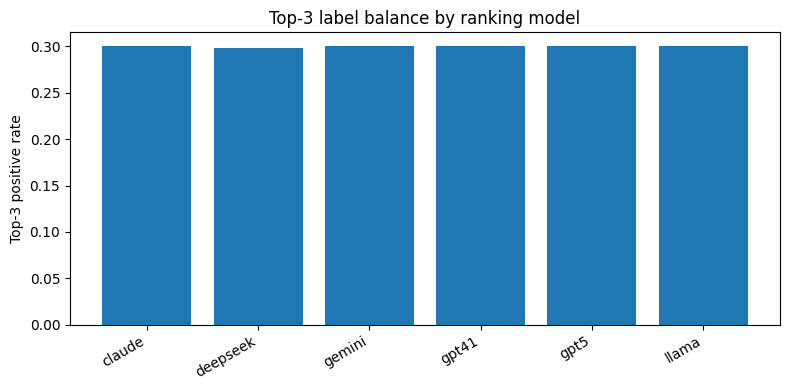

model,claude,deepseek,gemini,gpt41,gpt5,llama
model,,,,,,
claude,1.000000,0.664768,0.673679,0.674977,0.577588,0.614887
deepseek,0.664768,1.000000,0.644677,0.647146,0.543483,0.640175
gemini,0.673679,0.644677,1.000000,0.722586,0.616951,0.570900
gpt41,0.674977,0.647146,0.722586,1.000000,0.601221,0.602763
gpt5,0.577588,0.543483,0.616951,0.601221,1.000000,0.483279
llama,0.614887,0.640175,0.570900,0.602763,0.483279,1.000000


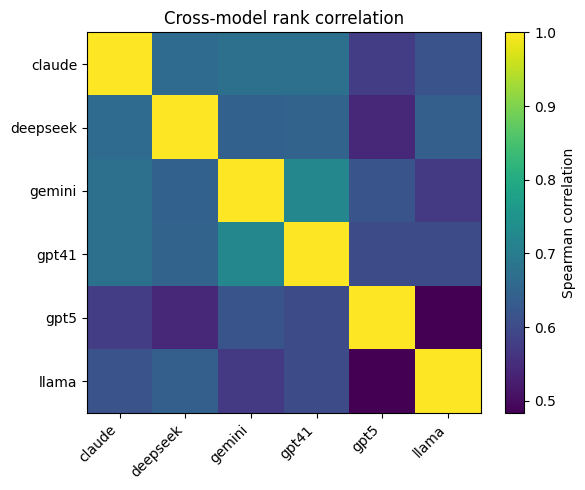

In [10]:
balance_table = (
    train_long_df.groupby("model")["top3"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "top3_rate", "count": "n_rows"})
    .reset_index()
)
balance_table.to_csv(DATA_DIR / "egeo_top3_balance_by_model.csv", index=False)
display(balance_table)

plt.figure(figsize=(8, 4))
plt.bar(balance_table["model"], balance_table["top3_rate"])
plt.ylabel("Top-3 positive rate")
plt.title("Top-3 label balance by ranking model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top3_balance_by_model.png", dpi=200)
plt.show()

model_rank_matrix = rank_pivot[rank_cols]
corr = model_rank_matrix.corr(method="spearman")
corr.to_csv(DATA_DIR / "egeo_rank_spearman_correlation_across_models.csv")

display(corr)

plt.figure(figsize=(6, 5))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Cross-model rank correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cross_model_rank_correlation.png", dpi=200)
plt.show()


## 9. Train/validation split by query_id

In [11]:
EXCLUDE_QUESTIONABLE = False

df_model = target_train_df.copy()
if EXCLUDE_QUESTIONABLE:
    df_model = df_model[df_model["questionable"] == 0].copy()

groups = df_model["query_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(splitter.split(df_model, df_model["top3"], groups=groups))

train_df = df_model.iloc[train_idx].reset_index(drop=True)
valid_df = df_model.iloc[valid_idx].reset_index(drop=True)

train_df, valid_df, cosine_vectorizer = add_tfidf_similarity_split(train_df, valid_df)

print("Train rows:", train_df.shape, "Train queries:", train_df["query_id"].nunique())
print("Valid rows:", valid_df.shape, "Valid queries:", valid_df["query_id"].nunique())

print("\nTrain top3 balance:")
display(train_df["top3"].value_counts(normalize=True))
print("\nValid top3 balance:")
display(valid_df["top3"].value_counts(normalize=True))

train_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_internal_train_split.csv", index=False)
valid_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_internal_valid_split.csv", index=False)


Train rows: (15680, 50) Train queries: 1568
Valid rows: (3920, 50) Valid queries: 392

Train top3 balance:


,proportion
top3,
0,0.7
1,0.3



Valid top3 balance:


,proportion
top3,
0,0.7
1,0.3


## 10. Feature sets

In [12]:
TEXT_COL = "query_product_pair_text"

BASE_NUMERIC_FEATURES = [
    "price",
    "average_rating",
    "rating_number",
    "log_rating_number",
    "log_price",
    "feature_count",
    "description_item_count",
    "details_item_count",
    "query_len_words",
    "title_len_words",
    "product_text_len_words",
    "features_len_words",
    "description_len_words",
    "details_len_words",
    "has_price",
    "has_rating",
    "has_rating_number",
    "has_description",
    "has_details",
    "has_store",
    "numeric_count_product_text",
    "numeric_count_title",
    "numeric_count_features",
    "numeric_count_details",
    "evidence_keyword_count",
    "query_title_overlap",
    "query_features_overlap",
    "query_product_overlap",
    "tfidf_query_product_cosine",
]

NUMERIC_FEATURES = [c for c in BASE_NUMERIC_FEATURES if c in train_df.columns]

print("Number of numeric features:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)


Number of numeric features: 29
['price', 'average_rating', 'rating_number', 'log_rating_number', 'log_price', 'feature_count', 'description_item_count', 'details_item_count', 'query_len_words', 'title_len_words', 'product_text_len_words', 'features_len_words', 'description_len_words', 'details_len_words', 'has_price', 'has_rating', 'has_rating_number', 'has_description', 'has_details', 'has_store', 'numeric_count_product_text', 'numeric_count_title', 'numeric_count_features', 'numeric_count_details', 'evidence_keyword_count', 'query_title_overlap', 'query_features_overlap', 'query_product_overlap', 'tfidf_query_product_cosine']


## 11. Evaluation utilities

In [13]:
def classification_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "AUROC": roc_auc_score(y_true, y_proba),
        "AUPRC": average_precision_score(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }


def query_level_metrics(eval_df, score_col="pred_score", label_col="top3", k=3):
    def precision_at_k(group):
        g = group.sort_values(score_col, ascending=False).head(k)
        return g[label_col].mean()

    def recall_at_k(group):
        true_total = group[label_col].sum()
        if true_total == 0:
            return np.nan
        g = group.sort_values(score_col, ascending=False).head(k)
        return g[label_col].sum() / true_total

    def ndcg_at_k(group):
        g = group.sort_values(score_col, ascending=False).head(k)
        rel = g[label_col].to_numpy()
        dcg = sum(rel[i] / math.log2(i + 2) for i in range(len(rel)))

        ideal = np.sort(group[label_col].to_numpy())[::-1][:k]
        idcg = sum(ideal[i] / math.log2(i + 2) for i in range(len(ideal)))
        return dcg / idcg if idcg > 0 else np.nan

    q = eval_df.groupby("query_id").apply(
        lambda g: pd.Series({
            f"precision@{k}": precision_at_k(g),
            f"recall@{k}": recall_at_k(g),
            f"ndcg@{k}": ndcg_at_k(g),
        })
    )
    return q


def save_model_results(model_name, valid_df, y_true, y_proba, metrics_rows, query_metric_rows):
    row_metrics = classification_metrics(y_true, y_proba)
    row_metrics["model"] = model_name
    metrics_rows.append(row_metrics)

    eval_df = valid_df.copy()
    eval_df["pred_score"] = y_proba
    q_metrics = query_level_metrics(eval_df, score_col="pred_score", label_col="top3", k=3)

    q_summary = q_metrics.mean().to_dict()
    q_summary["model"] = model_name
    query_metric_rows.append(q_summary)

    pred_path = DATA_DIR / f"predictions_valid_{TARGET_MODEL}_{model_name}.csv"
    eval_df[["query_id", "product_num", "product_id", "title", "rank", "top3", "pred_score"]].to_csv(pred_path, index=False)

    return row_metrics, q_metrics


## 12. Build classification baseline models

In [14]:
X_train_textnum = train_df[[TEXT_COL] + NUMERIC_FEATURES]
X_valid_textnum = valid_df[[TEXT_COL] + NUMERIC_FEATURES]

X_train_num = train_df[NUMERIC_FEATURES]
X_valid_num = valid_df[NUMERIC_FEATURES]

y_train = train_df["top3"].astype(int)
y_valid = valid_df["top3"].astype(int)

numeric_preprocess_dense = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_preprocess_sparse = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

text_vectorizer = TfidfVectorizer(
    max_features=60000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    lowercase=True,
    strip_accents="unicode",
)

textnum_preprocess = ColumnTransformer(
    transformers=[
        ("text", text_vectorizer, TEXT_COL),
        ("num", numeric_preprocess_sparse, NUMERIC_FEATURES),
    ],
    remainder="drop",
)

text_only_preprocess = ColumnTransformer(
    transformers=[
        ("text", text_vectorizer, TEXT_COL),
    ],
    remainder="drop",
)

text_svd_preprocess = ColumnTransformer(
    transformers=[
        ("text_svd", Pipeline([
            ("tfidf", TfidfVectorizer(
                max_features=60000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                lowercase=True,
                strip_accents="unicode",
            )),
            ("svd", TruncatedSVD(n_components=200, random_state=42)),
            ("scaler", StandardScaler()),
        ]), TEXT_COL),
        ("num", numeric_preprocess_dense, NUMERIC_FEATURES),
    ],
    remainder="drop",
)

models = {
    "numeric_logreg": Pipeline([
        ("prep", numeric_preprocess_dense),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "numeric_random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "numeric_extra_trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=3,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "numeric_hist_gradient_boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            l2_regularization=0.1,
            random_state=42,
        )),
    ]),
    "text_tfidf_logreg": Pipeline([
        ("prep", text_only_preprocess),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "textnum_tfidf_logreg": Pipeline([
        ("prep", textnum_preprocess),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="saga",
            n_jobs=-1,
            random_state=42,
        )),
    ]),
    "textnum_tfidf_sgd_logloss": Pipeline([
        ("prep", textnum_preprocess),
        ("clf", SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    "textsvd_num_logreg": Pipeline([
        ("prep", text_svd_preprocess),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
}

try:
    from xgboost import XGBClassifier
    models["numeric_xgboost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
        )),
    ])
    print("XGBoost detected: added numeric_xgboost.")
except Exception as e:
    print("XGBoost not available, skipping. Reason:", e)

try:
    from lightgbm import LGBMClassifier
    models["numeric_lightgbm"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", LGBMClassifier(
            n_estimators=400,
            max_depth=-1,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )),
    ])
    print("LightGBM detected: added numeric_lightgbm.")
except Exception as e:
    print("LightGBM not available, skipping. Reason:", e)

print("Models to run:")
for m in models:
    print(" -", m)


XGBoost detected: added numeric_xgboost.
LightGBM detected: added numeric_lightgbm.
Models to run:
 - numeric_logreg
 - numeric_random_forest
 - numeric_extra_trees
 - numeric_hist_gradient_boosting
 - text_tfidf_logreg
 - textnum_tfidf_logreg
 - textnum_tfidf_sgd_logloss
 - textsvd_num_logreg
 - numeric_xgboost
 - numeric_lightgbm


## 13. Run all classification baselines

In [15]:
metrics_rows = []
query_metric_rows = []
trained_models = {}

for model_name, model in models.items():
    print("\n" + "=" * 80)
    print("Training:", model_name)

    if model_name.startswith("numeric_"):
        Xtr, Xva = X_train_num, X_valid_num
    else:
        Xtr, Xva = X_train_textnum, X_valid_textnum

    try:
        model.fit(Xtr, y_train)

        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(Xva)[:, 1]
        else:
            scores = model.decision_function(Xva)
            y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

        row_metrics, q_metrics = save_model_results(
            model_name=model_name,
            valid_df=valid_df,
            y_true=y_valid,
            y_proba=y_proba,
            metrics_rows=metrics_rows,
            query_metric_rows=query_metric_rows,
        )

        trained_models[model_name] = model
        print(pd.Series(row_metrics))

    except Exception as e:
        print(f"FAILED: {model_name}")
        print("Reason:", repr(e))

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("AUPRC", ascending=False)
query_metrics_df = pd.DataFrame(query_metric_rows).set_index("model").sort_values("ndcg@3", ascending=False)

metrics_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_classification_metrics_valid.csv")
query_metrics_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_query_level_metrics_valid.csv")

display(metrics_df)
display(query_metrics_df)

for model_name, model in trained_models.items():
    joblib.dump(model, MODELS_DIR / f"{TARGET_MODEL}_{model_name}.joblib")



Training: numeric_logreg
AUROC              0.56454
AUPRC             0.352838
Accuracy          0.555867
F1                0.407218
model       numeric_logreg
dtype: object

Training: numeric_random_forest
AUROC                    0.578469
AUPRC                    0.372358
Accuracy                 0.685204
F1                        0.22875
model       numeric_random_forest
dtype: object

Training: numeric_extra_trees
AUROC                  0.580945
AUPRC                  0.375468
Accuracy               0.677806
F1                     0.288451
model       numeric_extra_trees
dtype: object

Training: numeric_hist_gradient_boosting
AUROC                             0.563498
AUPRC                             0.355206
Accuracy                           0.69949
F1                                0.006745
model       numeric_hist_gradient_boosting
dtype: object

Training: text_tfidf_logreg
AUROC                0.608056
AUPRC                0.398992
Accuracy             0.602551
F1           

,AUROC,AUPRC,Accuracy,F1
model,,,,
textnum_tfidf_logreg,0.614530,0.405063,0.606122,0.442197
text_tfidf_logreg,0.608056,0.398992,0.602551,0.428047
textnum_tfidf_sgd_logloss,0.597177,0.386208,0.692857,0.155680
textsvd_num_logreg,0.597364,0.381246,0.576276,0.445038
numeric_extra_trees,0.580945,0.375468,0.677806,0.288451
numeric_random_forest,0.578469,0.372358,0.685204,0.228750
numeric_xgboost,0.564415,0.359848,0.697959,0.082171
numeric_hist_gradient_boosting,0.563498,0.355206,0.699490,0.006745
numeric_lightgbm,0.562189,0.354644,0.595918,0.370929


,precision@3,recall@3,ndcg@3
model,,,
textnum_tfidf_logreg,0.426871,0.426871,0.445588
textnum_tfidf_sgd_logloss,0.418367,0.418367,0.435669
text_tfidf_logreg,0.420918,0.420918,0.432619
textsvd_num_logreg,0.399660,0.399660,0.416800
numeric_extra_trees,0.377551,0.377551,0.392045
numeric_xgboost,0.366497,0.366497,0.376924
numeric_random_forest,0.364796,0.364796,0.376639
numeric_logreg,0.368197,0.368197,0.376269
numeric_lightgbm,0.362245,0.362245,0.366748


## 14. Metrics figures

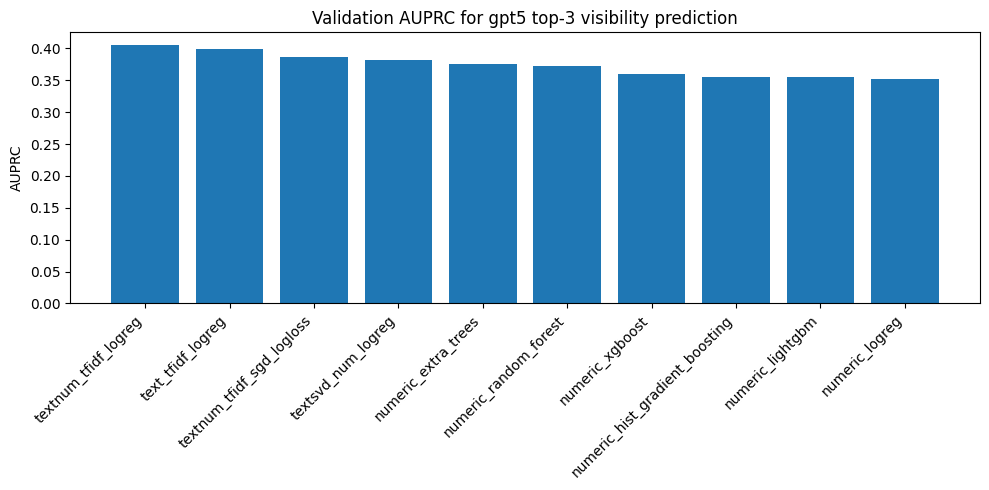

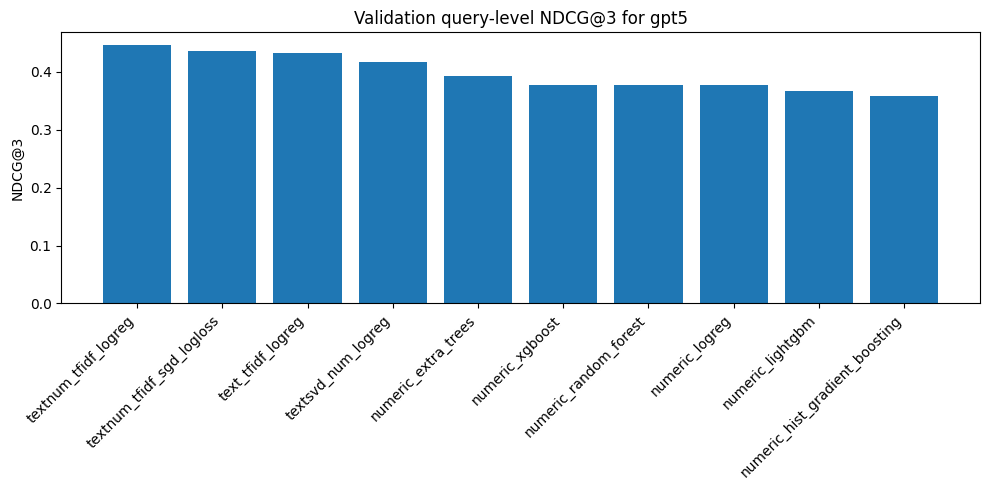

Best row-level model by AUPRC: textnum_tfidf_logreg
Best predictions saved at: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/predictions_valid_gpt5_textnum_tfidf_logreg.csv


In [16]:
if len(metrics_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(metrics_df.index, metrics_df["AUPRC"])
    plt.ylabel("AUPRC")
    plt.title(f"Validation AUPRC for {TARGET_MODEL} top-3 visibility prediction")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{TARGET_MODEL}_classification_auprc.png", dpi=200)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(query_metrics_df.index, query_metrics_df["ndcg@3"])
    plt.ylabel("NDCG@3")
    plt.title(f"Validation query-level NDCG@3 for {TARGET_MODEL}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"{TARGET_MODEL}_query_level_ndcg3.png", dpi=200)
    plt.show()

best_model_name = metrics_df.index[0]
best_pred_path = DATA_DIR / f"predictions_valid_{TARGET_MODEL}_{best_model_name}.csv"
print("Best row-level model by AUPRC:", best_model_name)
print("Best predictions saved at:", best_pred_path)


## 15. Feature importance for tree models

,model,feature,importance
28,numeric_random_forest,tfidf_query_product_cosine,0.068925
10,numeric_random_forest,product_text_len_words,0.061133
27,numeric_random_forest,query_product_overlap,0.059096
25,numeric_random_forest,query_title_overlap,0.058604
11,numeric_random_forest,features_len_words,0.056177
26,numeric_random_forest,query_features_overlap,0.055185
8,numeric_random_forest,query_len_words,0.055044
13,numeric_random_forest,details_len_words,0.051230
3,numeric_random_forest,log_rating_number,0.049694
2,numeric_random_forest,rating_number,0.049292


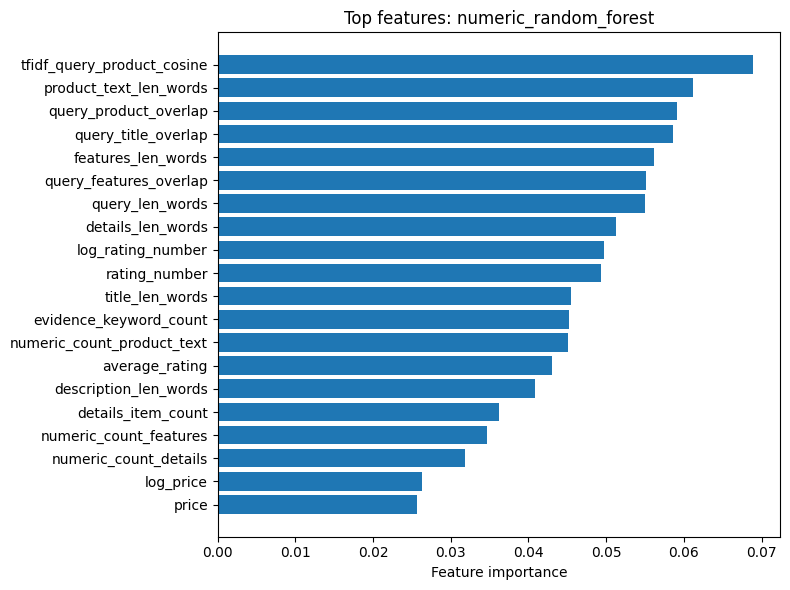

,model,feature,importance
1,numeric_extra_trees,average_rating,0.055460
3,numeric_extra_trees,log_rating_number,0.053145
9,numeric_extra_trees,title_len_words,0.050057
7,numeric_extra_trees,details_item_count,0.047540
22,numeric_extra_trees,numeric_count_features,0.047471
11,numeric_extra_trees,features_len_words,0.047086
28,numeric_extra_trees,tfidf_query_product_cosine,0.046970
8,numeric_extra_trees,query_len_words,0.046948
26,numeric_extra_trees,query_features_overlap,0.046207
24,numeric_extra_trees,evidence_keyword_count,0.045586


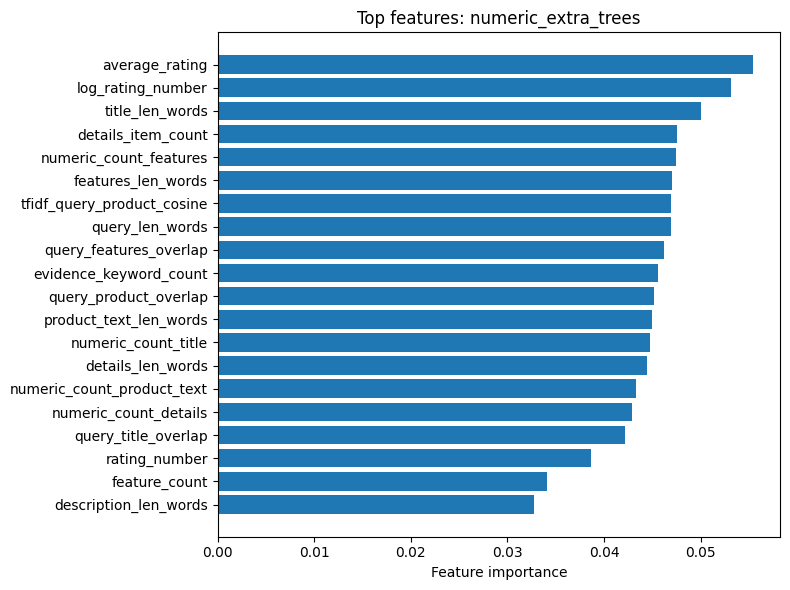

,model,feature,importance
4,numeric_xgboost,log_price,0.067818
0,numeric_xgboost,price,0.056543
2,numeric_xgboost,rating_number,0.042827
6,numeric_xgboost,description_item_count,0.041488
3,numeric_xgboost,log_rating_number,0.041305
1,numeric_xgboost,average_rating,0.040864
12,numeric_xgboost,description_len_words,0.040373
10,numeric_xgboost,product_text_len_words,0.039749
22,numeric_xgboost,numeric_count_features,0.039450
26,numeric_xgboost,query_features_overlap,0.039103


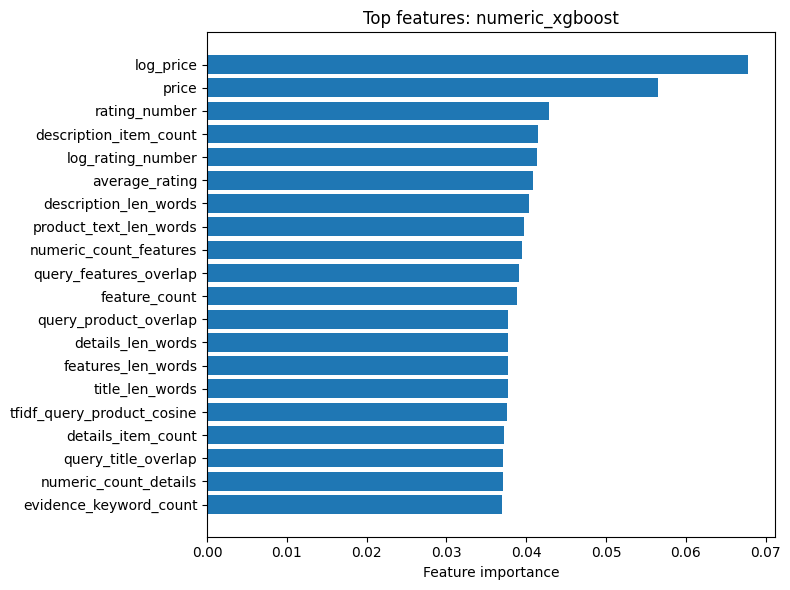

,model,feature,importance
28,numeric_lightgbm,tfidf_query_product_cosine,884
2,numeric_lightgbm,rating_number,829
10,numeric_lightgbm,product_text_len_words,763
27,numeric_lightgbm,query_product_overlap,754
8,numeric_lightgbm,query_len_words,709
26,numeric_lightgbm,query_features_overlap,675
13,numeric_lightgbm,details_len_words,668
25,numeric_lightgbm,query_title_overlap,665
24,numeric_lightgbm,evidence_keyword_count,643
11,numeric_lightgbm,features_len_words,637


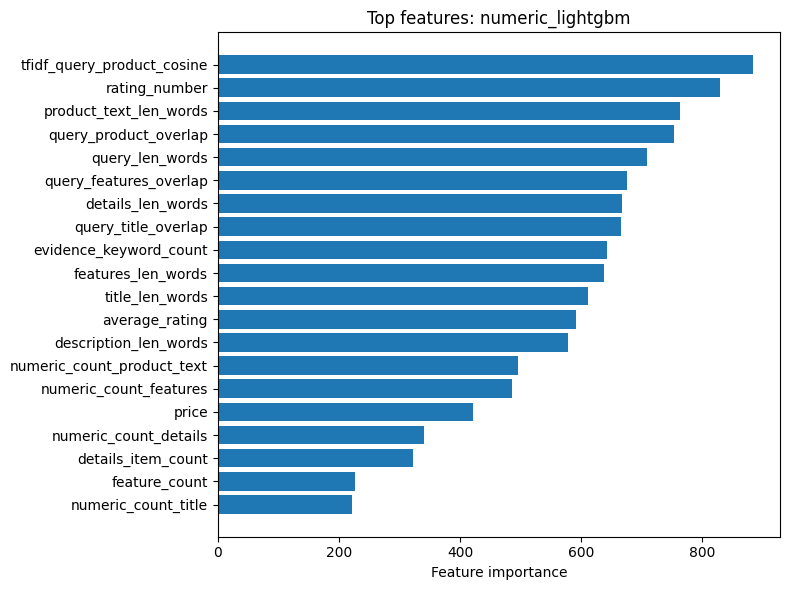

In [17]:
feature_importance_tables = []

for model_name in ["numeric_random_forest", "numeric_extra_trees", "numeric_xgboost", "numeric_lightgbm"]:
    if model_name not in trained_models:
        continue

    model = trained_models[model_name]
    clf = model.named_steps["clf"]

    if hasattr(clf, "feature_importances_"):
        imp = pd.DataFrame({
            "model": model_name,
            "feature": NUMERIC_FEATURES,
            "importance": clf.feature_importances_,
        }).sort_values("importance", ascending=False)

        feature_importance_tables.append(imp)
        imp.to_csv(DATA_DIR / f"feature_importance_{TARGET_MODEL}_{model_name}.csv", index=False)

        display(imp.head(20))

        plt.figure(figsize=(8, 6))
        top = imp.head(20).iloc[::-1]
        plt.barh(top["feature"], top["importance"])
        plt.xlabel("Feature importance")
        plt.title(f"Top features: {model_name}")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"feature_importance_{TARGET_MODEL}_{model_name}.png", dpi=200)
        plt.show()

if feature_importance_tables:
    all_importances = pd.concat(feature_importance_tables, ignore_index=True)
    all_importances.to_csv(DATA_DIR / f"feature_importance_{TARGET_MODEL}_all_tree_models.csv", index=False)
else:
    print("No tree feature-importance tables available.")


## 16. Logistic regression coefficients

In [18]:
def extract_logreg_coefficients(model, model_name, top_n=50):
    if "prep" not in model.named_steps or "clf" not in model.named_steps:
        return None

    prep = model.named_steps["prep"]
    clf = model.named_steps["clf"]

    if not hasattr(clf, "coef_"):
        return None

    try:
        feature_names = prep.get_feature_names_out()
    except Exception:
        return None

    coef = clf.coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
    }).sort_values("coef", ascending=False)

    coef_df.to_csv(DATA_DIR / f"coefficients_{TARGET_MODEL}_{model_name}.csv", index=False)

    print("\nMost positive coefficients:", model_name)
    display(coef_df.head(top_n))

    print("\nMost negative coefficients:", model_name)
    display(coef_df.tail(top_n).sort_values("coef"))

    return coef_df

for model_name in ["text_tfidf_logreg", "textnum_tfidf_logreg", "textsvd_num_logreg", "numeric_logreg"]:
    if model_name in trained_models:
        extract_logreg_coefficients(trained_models[model_name], model_name, top_n=30)



Most positive coefficients: text_tfidf_logreg


,feature,coef
57588,text__with,2.264880
3197,text__adjustable,1.408431
56002,text__waterproof,1.327927
25298,text__hour,1.272775
2662,text__90,1.270137
10013,text__brenthaven,1.258433
31541,text__master,1.251436
42231,text__remote,1.231572
12858,text__coating,1.222303
11381,text__cards,1.212817



Most negative coefficients: text_tfidf_logreg


,feature,coef
46189,text__soft,-1.584963
42716,text__retro,-1.387115
39304,text__portable,-1.324800
27652,text__it,-1.281851
16564,text__dog,-1.217840
9849,text__brand new,-1.185789
35547,text__office,-1.180523
22735,text__girls,-1.178649
8680,text__bench,-1.154911
43610,text__saving,-1.110622



Most positive coefficients: textnum_tfidf_logreg


...

,feature,coef
217,num__has_description,-0.108062
20,text_svd__truncatedsvd20,-0.091823
208,num__query_len_words,-0.086149
1,text_svd__truncatedsvd1,-0.074659
196,text_svd__truncatedsvd196,-0.055282
60,text_svd__truncatedsvd60,-0.054676
25,text_svd__truncatedsvd25,-0.052274
34,text_svd__truncatedsvd34,-0.048883
136,text_svd__truncatedsvd136,-0.046181
79,text_svd__truncatedsvd79,-0.045269



Most positive coefficients: numeric_logreg


,feature,coef
4,log_price,0.155415
2,rating_number,0.093890
27,query_product_overlap,0.093195
1,average_rating,0.082414
19,has_store,0.046248
22,numeric_count_features,0.044435
5,feature_count,0.044412
12,description_len_words,0.039098
21,numeric_count_title,0.034869
23,numeric_count_details,0.032086



Most negative coefficients: numeric_logreg


,feature,coef
17,has_description,-0.098045
11,features_len_words,-0.059086
9,title_len_words,-0.059016
6,description_item_count,-0.034186
26,query_features_overlap,-0.033797
0,price,-0.019295
25,query_title_overlap,-0.018558
7,details_item_count,-0.013242
24,evidence_keyword_count,-0.005600
10,product_text_len_words,-0.003008


## 17. Regression baseline: predict visibility_score

In [19]:
y_train_reg = train_df["visibility_score"].astype(float)
y_valid_reg = valid_df["visibility_score"].astype(float)

regressors = {
    "textnum_tfidf_ridge": Pipeline([
        ("prep", textnum_preprocess),
        ("reg", Ridge(alpha=1.0, random_state=42)),
    ]),
    "numeric_random_forest_regressor": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("reg", RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42,
        )),
    ]),
}

regression_rows = []

for model_name, reg in regressors.items():
    print("\n" + "=" * 80)
    print("Training regression model:", model_name)

    if model_name.startswith("numeric_"):
        Xtr, Xva = X_train_num, X_valid_num
    else:
        Xtr, Xva = X_train_textnum, X_valid_textnum

    try:
        reg.fit(Xtr, y_train_reg)
        pred = reg.predict(Xva)

        try:
            rmse = mean_squared_error(y_valid_reg, pred, squared=False)
        except TypeError:
            rmse = mean_squared_error(y_valid_reg, pred) ** 0.5

        mae = mean_absolute_error(y_valid_reg, pred)
        pearson = pd.Series(y_valid_reg).corr(pd.Series(pred), method="pearson")
        spearman = pd.Series(y_valid_reg).corr(pd.Series(pred), method="spearman")

        row = {
            "model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "Pearson": pearson,
            "Spearman": spearman,
        }
        regression_rows.append(row)

        eval_reg = valid_df.copy()
        eval_reg["pred_visibility_score"] = pred
        eval_reg.to_csv(DATA_DIR / f"predictions_valid_{TARGET_MODEL}_{model_name}.csv", index=False)

        print(pd.Series(row))

    except Exception as e:
        print("FAILED:", model_name, repr(e))

regression_df = pd.DataFrame(regression_rows).set_index("model")
regression_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_visibility_score_regression_metrics.csv")
display(regression_df)



Training regression model: textnum_tfidf_ridge
model       textnum_tfidf_ridge
RMSE                   0.263484
MAE                    0.189673
Pearson                0.200465
Spearman               0.194424
dtype: object

Training regression model: numeric_random_forest_regressor
model       numeric_random_forest_regressor
RMSE                               0.260584
MAE                                0.190897
Pearson                            0.156129
Spearman                           0.140241
dtype: object


,RMSE,MAE,Pearson,Spearman
model,,,,
textnum_tfidf_ridge,0.263484,0.189673,0.200465,0.194424
numeric_random_forest_regressor,0.260584,0.190897,0.156129,0.140241


## 18. Optional learning-to-rank baseline

In [20]:
try:
    from xgboost import XGBRanker

    def prepare_ranker_data(df_in, features):
        out = df_in.sort_values(["query_id", "product_num"]).copy()
        X = out[features].copy()
        y = out["relevance_score"].astype(float)
        group = out.groupby("query_id").size().to_list()
        return out, X, y, group

    rank_train_df, X_rank_train, y_rank_train, group_train = prepare_ranker_data(train_df, NUMERIC_FEATURES)
    rank_valid_df, X_rank_valid, y_rank_valid, group_valid = prepare_ranker_data(valid_df, NUMERIC_FEATURES)

    imputer = SimpleImputer(strategy="median")
    X_rank_train_imp = imputer.fit_transform(X_rank_train)
    X_rank_valid_imp = imputer.transform(X_rank_valid)

    ranker = XGBRanker(
        objective="rank:ndcg",
        eval_metric="ndcg@3",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    )

    ranker.fit(X_rank_train_imp, y_rank_train, group=group_train)
    rank_scores = ranker.predict(X_rank_valid_imp)

    rank_eval = rank_valid_df.copy()
    rank_eval["pred_score"] = rank_scores

    rank_q_metrics = query_level_metrics(rank_eval, score_col="pred_score", label_col="top3", k=3)
    rank_q_summary = rank_q_metrics.mean().to_frame("xgboost_ranker_numeric")

    rank_eval.to_csv(DATA_DIR / f"predictions_valid_{TARGET_MODEL}_xgboost_ranker_numeric.csv", index=False)
    rank_q_metrics.to_csv(DATA_DIR / f"query_metrics_valid_{TARGET_MODEL}_xgboost_ranker_numeric.csv")

    display(rank_q_summary)

    rank_imp = pd.DataFrame({
        "feature": NUMERIC_FEATURES,
        "importance": ranker.feature_importances_,
    }).sort_values("importance", ascending=False)
    rank_imp.to_csv(DATA_DIR / f"feature_importance_{TARGET_MODEL}_xgboost_ranker_numeric.csv", index=False)
    display(rank_imp.head(20))

except Exception as e:
    print("XGBoost Ranker skipped. Reason:", repr(e))


,xgboost_ranker_numeric
precision@3,0.366497
recall@3,0.366497
ndcg@3,0.379076


,feature,importance
0,price,0.066254
4,log_price,0.065790
2,rating_number,0.043098
12,description_len_words,0.041243
13,details_len_words,0.040990
3,log_rating_number,0.040447
6,description_item_count,0.040396
1,average_rating,0.038414
26,query_features_overlap,0.036952
11,features_len_words,0.036917


## 19. Official test-set evaluation

In [21]:
if target_test_df is not None:
    test_df = target_test_df.copy()

    test_q = cosine_vectorizer.transform(test_df["query"].fillna(""))
    test_p = cosine_vectorizer.transform(test_df["product_text"].fillna(""))
    test_df["tfidf_query_product_cosine"] = np.asarray(test_q.multiply(test_p).sum(axis=1)).ravel()

    X_test_textnum = test_df[[TEXT_COL] + NUMERIC_FEATURES]
    X_test_num = test_df[NUMERIC_FEATURES]
    y_test = test_df["top3"].astype(int)

    test_metrics_rows = []
    test_query_metric_rows = []

    for model_name, model in trained_models.items():
        print("\nEvaluating on official test:", model_name)

        if model_name.startswith("numeric_"):
            Xte = X_test_num
        else:
            Xte = X_test_textnum

        try:
            y_proba = model.predict_proba(Xte)[:, 1]
            row_metrics, q_metrics = save_model_results(
                model_name=f"official_test_{model_name}",
                valid_df=test_df,
                y_true=y_test,
                y_proba=y_proba,
                metrics_rows=test_metrics_rows,
                query_metric_rows=test_query_metric_rows,
            )
            print(pd.Series(row_metrics))
        except Exception as e:
            print("FAILED:", model_name, repr(e))

    test_metrics_df = pd.DataFrame(test_metrics_rows).set_index("model").sort_values("AUPRC", ascending=False)
    test_query_metrics_df = pd.DataFrame(test_query_metric_rows).set_index("model").sort_values("ndcg@3", ascending=False)

    test_metrics_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_classification_metrics_official_test.csv")
    test_query_metrics_df.to_csv(DATA_DIR / f"egeo_{TARGET_MODEL}_query_level_metrics_official_test.csv")

    display(test_metrics_df)
    display(test_query_metrics_df)
else:
    print("No official target test dataset available, skipping.")



Evaluating on official test: numeric_logreg
AUROC                           0.571165
AUPRC                           0.361527
Accuracy                        0.564485
F1                              0.410278
model       official_test_numeric_logreg
dtype: object

Evaluating on official test: numeric_random_forest
AUROC                                  0.587475
AUPRC                                  0.377388
Accuracy                               0.687164
F1                                     0.216916
model       official_test_numeric_random_forest
dtype: object

Evaluating on official test: numeric_extra_trees
AUROC                                0.587532
AUPRC                                0.379634
Accuracy                             0.674784
F1                                   0.288568
model       official_test_numeric_extra_trees
dtype: object

Evaluating on official test: numeric_hist_gradient_boosting
AUROC                                           0.569858
AUPRC             

,AUROC,AUPRC,Accuracy,F1
model,,,,
official_test_textnum_tfidf_logreg,0.615518,0.399809,0.606596,0.434510
official_test_text_tfidf_logreg,0.604412,0.387452,0.611314,0.424461
official_test_textnum_tfidf_sgd_logloss,0.601346,0.383387,0.696753,0.154238
official_test_textsvd_num_logreg,0.599147,0.382260,0.571385,0.439565
official_test_numeric_extra_trees,0.587532,0.379634,0.674784,0.288568
official_test_numeric_random_forest,0.587475,0.377388,0.687164,0.216916
official_test_numeric_logreg,0.571165,0.361527,0.564485,0.410278
official_test_numeric_lightgbm,0.569604,0.359849,0.605327,0.375331
official_test_numeric_xgboost,0.573124,0.359273,0.697920,0.080037


,precision@3,recall@3,ndcg@3
model,,,
official_test_textnum_tfidf_logreg,0.428209,0.428209,0.442149
official_test_text_tfidf_logreg,0.412143,0.412143,0.424743
official_test_textsvd_num_logreg,0.413327,0.413327,0.424737
official_test_textnum_tfidf_sgd_logloss,0.408084,0.408084,0.422872
official_test_numeric_random_forest,0.387959,0.387959,0.402076
official_test_numeric_extra_trees,0.385422,0.385422,0.400370
official_test_numeric_logreg,0.374937,0.374937,0.386657
official_test_numeric_lightgbm,0.371554,0.371554,0.383664
official_test_numeric_xgboost,0.372400,0.372400,0.381433


## 20. Cross-model robustness analysis


################################################################################
Cross-model label: claude
claude textnum_tfidf_logreg {'AUROC': np.float64(0.6388223214285714), 'AUPRC': np.float64(0.4286848972645719), 'Accuracy': 0.62525, 'F1': 0.46137261947538627, 'label_model': 'claude', 'baseline_model': 'textnum_tfidf_logreg', 'precision@3': 0.44083333333333313, 'recall@3': 0.44083333333333313, 'ndcg@3': 0.45953918089034146}
claude numeric_random_forest {'AUROC': np.float64(0.6030726190476191), 'AUPRC': np.float64(0.4004261146338728), 'Accuracy': 0.69275, 'F1': 0.2924582613701785, 'label_model': 'claude', 'baseline_model': 'numeric_random_forest', 'precision@3': 0.41000000000000036, 'recall@3': 0.41000000000000036, 'ndcg@3': 0.42963713311619484}

################################################################################
Cross-model label: deepseek
deepseek textnum_tfidf_logreg {'AUROC': np.float64(0.6302742201867397), 'AUPRC': np.float64(0.41693203690368486), 'Accuracy': 0.6

,AUROC,AUPRC,Accuracy,F1,label_model,baseline_model,precision@3,recall@3,ndcg@3
1,0.603073,0.400426,0.692750,0.292458,claude,numeric_random_forest,0.410000,0.410000,0.429637
0,0.638822,0.428685,0.625250,0.461373,claude,textnum_tfidf_logreg,0.440833,0.440833,0.459539
3,0.590248,0.388744,0.694444,0.252830,deepseek,numeric_random_forest,0.391304,0.398977,0.409081
2,0.630274,0.416932,0.621142,0.448521,deepseek,textnum_tfidf_logreg,0.434783,0.440750,0.453677
5,0.588763,0.391906,0.684250,0.257496,gemini,numeric_random_forest,0.391667,0.391667,0.402947
4,0.623246,0.414432,0.615750,0.444123,gemini,textnum_tfidf_logreg,0.439167,0.439167,0.456830
7,0.574303,0.369361,0.678250,0.213806,gpt41,numeric_random_forest,0.380000,0.380000,0.389288
6,0.604402,0.401451,0.605250,0.427276,gpt41,textnum_tfidf_logreg,0.421667,0.421667,0.431145
9,0.577780,0.373089,0.686480,0.231395,gpt5,numeric_random_forest,0.369898,0.369898,0.380672
8,0.614530,0.405063,0.606122,0.442197,gpt5,textnum_tfidf_logreg,0.426871,0.426871,0.445588


baseline_model,numeric_random_forest,textnum_tfidf_logreg
label_model,,
claude,0.429637,0.459539
deepseek,0.409081,0.453677
gemini,0.402947,0.456830
gpt41,0.389288,0.431145
gpt5,0.380672,0.445588
llama,0.389549,0.452192


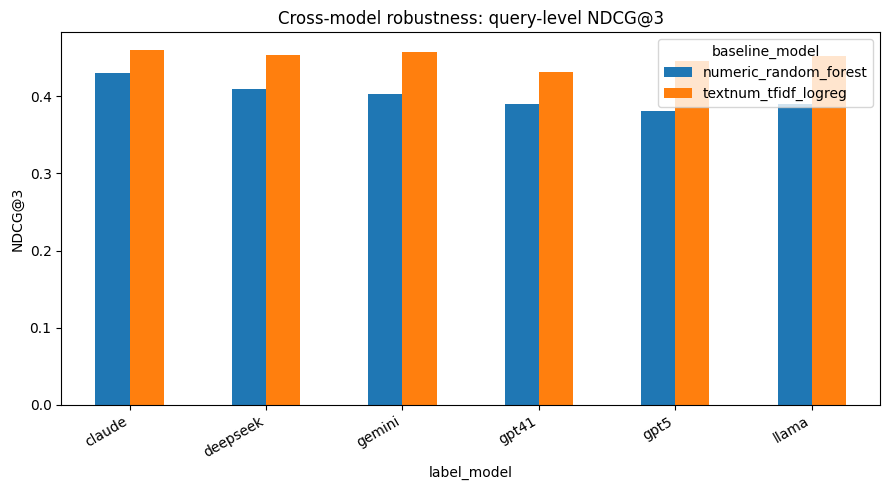

In [22]:
RUN_CROSS_MODEL_ROBUSTNESS = True

cross_model_rows = []

if RUN_CROSS_MODEL_ROBUSTNESS:
    available_models = sorted(train_long_df["model"].unique())

    for label_model in available_models:
        print("\n" + "#" * 80)
        print("Cross-model label:", label_model)

        df_m = train_long_df[train_long_df["model"] == label_model].copy()

        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        tr_idx, va_idx = next(splitter.split(df_m, df_m["top3"], groups=df_m["query_id"]))

        tr = df_m.iloc[tr_idx].reset_index(drop=True)
        va = df_m.iloc[va_idx].reset_index(drop=True)
        tr, va, _ = add_tfidf_similarity_split(tr, va)

        Xtr_textnum = tr[[TEXT_COL] + NUMERIC_FEATURES]
        Xva_textnum = va[[TEXT_COL] + NUMERIC_FEATURES]
        Xtr_num = tr[NUMERIC_FEATURES]
        Xva_num = va[NUMERIC_FEATURES]
        ytr = tr["top3"].astype(int)
        yva = va["top3"].astype(int)

        compact_models = {
            "textnum_tfidf_logreg": Pipeline([
                ("prep", textnum_preprocess),
                ("clf", LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    solver="saga",
                    n_jobs=-1,
                    random_state=42,
                )),
            ]),
            "numeric_random_forest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("clf", RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=42,
                )),
            ]),
        }

        for base_name, model in compact_models.items():
            try:
                if base_name.startswith("numeric_"):
                    Xtr, Xva = Xtr_num, Xva_num
                else:
                    Xtr, Xva = Xtr_textnum, Xva_textnum

                model.fit(Xtr, ytr)
                p = model.predict_proba(Xva)[:, 1]

                row = classification_metrics(yva, p)
                row["label_model"] = label_model
                row["baseline_model"] = base_name

                eval_m = va.copy()
                eval_m["pred_score"] = p
                q = query_level_metrics(eval_m, score_col="pred_score", label_col="top3", k=3).mean()

                row.update(q.to_dict())
                cross_model_rows.append(row)

                print(label_model, base_name, row)

            except Exception as e:
                print("FAILED:", label_model, base_name, repr(e))

cross_model_df = pd.DataFrame(cross_model_rows)
if len(cross_model_df) > 0:
    cross_model_df.to_csv(DATA_DIR / "egeo_cross_model_robustness_metrics.csv", index=False)
    display(cross_model_df.sort_values(["label_model", "AUPRC"]))

    pivot_ndcg = cross_model_df.pivot(index="label_model", columns="baseline_model", values="ndcg@3")
    pivot_ndcg.to_csv(DATA_DIR / "egeo_cross_model_ndcg3_pivot.csv")
    display(pivot_ndcg)

    pivot_ndcg.plot(kind="bar", figsize=(9, 5))
    plt.ylabel("NDCG@3")
    plt.title("Cross-model robustness: query-level NDCG@3")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "cross_model_robustness_ndcg3.png", dpi=200)
    plt.show()
else:
    print("No cross-model robustness results created.")


## 21. Final output checklist

After running this notebook, the most useful saved files are placed at the project-root sibling folders:

```text
E-GEO-ML/
├── data/
│   ├── egeo_train_val_products_flat.csv
│   ├── egeo_train_val_rankings_long.csv
│   ├── egeo_train_val_visibility_long_all_models.csv
│   ├── egeo_train_val_visibility_gpt5.csv
│   ├── egeo_train_val_model_agreement_features.csv
│   ├── egeo_gpt5_classification_metrics_valid.csv
│   ├── egeo_gpt5_query_level_metrics_valid.csv
│   └── egeo_cross_model_robustness_metrics.csv
├── figures/
│   ├── gpt5_classification_auprc.png
│   ├── gpt5_query_level_ndcg3.png
│   ├── cross_model_rank_correlation.png
│   └── cross_model_robustness_ndcg3.png
└── models/
    └── trained sklearn joblib files
```


## 22. Suggested interpretation paragraph

You can use this paragraph in an update to Professor Bian:

> I implemented a first E-GEO secondary-analysis pipeline using the public query-product data and precomputed model ranking traces, without making any new LLM API calls. The pipeline converts each shopping query into ten query-product observations and uses the existing LLM ranking position as a visibility label. The main task predicts whether a product appears in the top-3 of the LLM ranking from product text, query-product overlap, numeric/spec density, price/rating metadata, and evidence-richness features. I also added cross-model robustness using GPT-5, GPT-4.1, Gemini, Claude, DeepSeek, and Llama ranking files, plus query-level metrics such as precision@3, recall@3, and NDCG@3. This is not a direct old/current product-page adaptation test, but it is a scalable diagnostic analysis of what product-text features are associated with LLM shopping visibility in an existing public GEO benchmark.
